# Tumor Growth Modeling: Comparing Four Classical Growth Models

**Authors:** Aryan Pathak and Rohit Narwal  |  **Data:** CAUSE *Teaching Statistics in the Health Sciences* tumor-growth dataset (37 mice, 4 treatment groups)

**Question:** Which classical growth model (Exponential, Logistic, Gompertz, Power Law) best describes and best *predicts* tumor growth under four treatments?

**How to run this in Google Colab:** upload `tumor_growth_clean.csv` using the folder icon on the left, then choose *Runtime → Run all*.

**What this notebook does**
1. Reproduces the model fits from the draft paper (fit each model to the group-mean tumor volume per day).
2. Checks the data for a problem that affects how far those fits can be trusted (mice leaving the study).
3. Tests prediction honestly with a train/test split and reports error numbers.
4. Re-checks the conclusions by fitting each mouse individually.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

path = "tumor_growth_clean.csv" if os.path.exists("tumor_growth_clean.csv") else "data/tumor_growth_clean.csv"
df = pd.read_csv(path)

GROUPS = ["CONTROL", "DRUG", "RADIATION", "DRUG+RADIATION"]
COLORS = {"CONTROL": "#d62728", "DRUG": "#1f77b4", "RADIATION": "#2ca02c", "DRUG+RADIATION": "#9467bd"}
df.head()

,Mouse_ID,Treatment_Group,Day,Tumor_Volume_mm3
0,101,CONTROL,0,41.8
1,101,CONTROL,3,85.0
2,101,CONTROL,4,114.0
3,101,CONTROL,5,162.3
4,101,CONTROL,6,178.3


## 1. Data check
This reproduces Table 1 of the paper (mice, observations, day range, volume range, mean starting volume).

In [2]:
summary = df.groupby("Treatment_Group").agg(
    mice=("Mouse_ID", "nunique"),
    observations=("Day", "size"),
    first_day=("Day", "min"),
    last_day=("Day", "max"),
    min_volume=("Tumor_Volume_mm3", "min"),
    max_volume=("Tumor_Volume_mm3", "max"),
).loc[GROUPS]
summary["mean_initial_volume"] = df[df.Day == 0].groupby("Treatment_Group").Tumor_Volume_mm3.mean().round(1)
print("Total mice:", df.Mouse_ID.nunique(), "| Total measurements:", len(df), "| Missing values:", int(df.isna().sum().sum()))
summary

Total mice: 37 | Total measurements: 575 | Missing values: 0


,mice,observations,first_day,last_day,min_volume,max_volume,mean_initial_volume
Treatment_Group,,,,,,,
CONTROL,8,97,0,21,41.8,2405.7,55.6
DRUG,10,172,0,28,38.5,2269.3,51.8
RADIATION,10,161,0,28,40.7,2362.4,48.6
DRUG+RADIATION,9,145,0,28,41.3,2343.0,51.1


## 2. A problem to check before trusting the group-mean curves
The paper fits each model to the **average volume of the mice measured on each day**. But mice are not all measured for the same number of days. If tumors that grow large are removed from the study, the late-day averages come from only a few mice, and the biggest tumors are the ones missing. That can flatten the curve and make a "plateau" (carrying capacity) look real when it is partly an artifact.

The left chart shows a second issue: mice are not measured on the same days, so each daily average mixes a different handful of mice (anywhere from 1 to 10). That adds noise to the group-mean curves. The right chart shows that most mice left the study with large tumors.

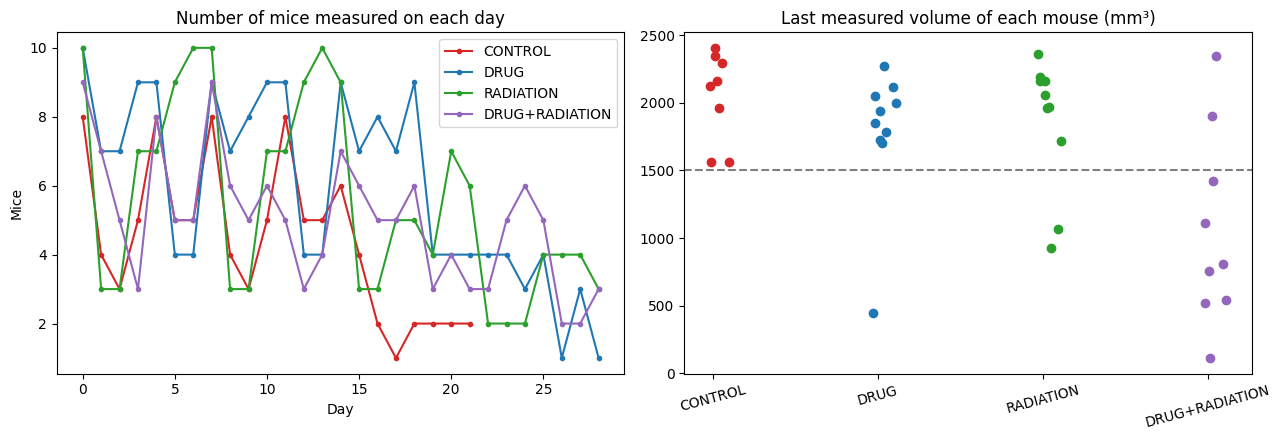

Mice whose LAST measurement was above 1500 mm³ (out of mice per group):
                 over_1500  mice
Treatment_Group                 
CONTROL                  8     8
DRUG                     9    10
RADIATION                8    10
DRUG+RADIATION           2     9

Drug group, mice per day at the end of the study:
{23: 4, 24: 3, 25: 4, 26: 1, 27: 3, 28: 1}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for g in GROUPS:
    n_per_day = df[df.Treatment_Group == g].groupby("Day").Mouse_ID.nunique()
    axes[0].plot(n_per_day.index, n_per_day.values, marker="o", ms=3, label=g, color=COLORS[g])
axes[0].set_title("Number of mice measured on each day")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Mice"); axes[0].legend()

last = df.sort_values("Day").groupby("Mouse_ID").tail(1)
for i, g in enumerate(GROUPS):
    v = last[last.Treatment_Group == g].Tumor_Volume_mm3
    axes[1].scatter(np.full(len(v), i) + np.random.RandomState(0).uniform(-.12, .12, len(v)), v, color=COLORS[g])
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(GROUPS, rotation=15)
axes[1].set_title("Last measured volume of each mouse (mm³)")
axes[1].axhline(1500, ls="--", color="gray")
plt.tight_layout(); plt.savefig("figures/dropout_check.png", dpi=150); plt.show()

big = (last.Tumor_Volume_mm3 > 1500).groupby(last.Treatment_Group).sum().reindex(GROUPS)
print("Mice whose LAST measurement was above 1500 mm³ (out of mice per group):")
print(pd.DataFrame({"over_1500": big, "mice": summary.mice}))
print("\nDrug group, mice per day at the end of the study:")
print(df[df.Treatment_Group == "DRUG"].groupby("Day").Mouse_ID.nunique().tail(6).to_dict())

## 3. The four models and the fitting helper

In [4]:
def expo(t, V0, r):      return V0 * np.exp(r * t)
def logi(t, V0, r, K):   return K / (1 + ((K - V0) / V0) * np.exp(-r * t))
def gomp(t, V0, r, K):   return K * np.exp(np.log(V0 / K) * np.exp(-r * t))
def powr(t, V0, a, b):   return V0 + a * t ** b

MODELS = {"Exponential": expo, "Logistic": logi, "Gompertz": gomp, "Power law": powr}

def fit_model(name, t, y, v0_bounds=None):
    """Nonlinear least squares with biologically sensible bounds.
    v0_bounds=None -> V0 is free (as in the draft paper).
    v0_bounds=(lo, hi) -> V0 is forced to stay near the observed starting volume."""
    f, Kmax = MODELS[name], y.max()
    if name == "Exponential":
        p0, lo, hi = [50, .1], [1e-3, 1e-4], [1e4, 2]
    elif name in ("Logistic", "Gompertz"):
        p0, lo, hi = [50, .3, Kmax], [1e-3, 1e-4, .5 * Kmax], [1e5, 5, 1e5]
    else:
        p0, lo, hi = [10, 10, 1.5], [0, 1e-4, .1], [1e4, 1e4, 5]
    if v0_bounds is not None:
        lo[0], hi[0] = v0_bounds
        p0[0] = np.clip(p0[0], *v0_bounds)
    p, _ = curve_fit(f, t, y, p0=p0, bounds=(lo, hi), maxfev=20000)
    return p

def score(y, yhat, k):
    n = len(y); ss = ((y - yhat) ** 2).sum()
    r2 = 1 - ss / ((y - y.mean()) ** 2).sum()
    aic = n * np.log(ss / n) + 2 * k
    aicc = aic + 2 * k * (k + 1) / (n - k - 1)
    return r2, np.sqrt(ss / n), aic, aicc

def group_mean(g):
    m = df[df.Treatment_Group == g].groupby("Day").Tumor_Volume_mm3.mean()
    return m.index.values.astype(float), m.values

## 4. Fit all four models to each group's mean curve (reproduces the paper's Section 3.2)

In [5]:
rows, fits = [], {}
for g in GROUPS:
    t, y = group_mean(g)
    for name in MODELS:
        p = fit_model(name, t, y)
        r2, rmse, aic, aicc = score(y, MODELS[name](t, *p), len(p))
        fits[(g, name)] = p
        rows.append({"Group": g, "Model": name, "R2": round(r2, 3), "RMSE": round(rmse, 1),
                     "AIC": round(aic, 1), "AICc": round(aicc, 1), "Days used": len(t)})
results = pd.DataFrame(rows)
best = results.loc[results.groupby("Group").AIC.idxmin(), ["Group", "Model", "R2", "AIC"]]
print("Best model by AIC in each group:"); print(best.to_string(index=False))
print("\nMean R² across the 4 groups:"); print(results.groupby("Model").R2.mean().round(3))
results

Best model by AIC in each group:
         Group    Model    R2   AIC
       CONTROL Logistic 0.941 228.3
          DRUG Logistic 0.816 324.8
DRUG+RADIATION Logistic 0.884 286.2
     RADIATION Gompertz 0.918 293.7

Mean R² across the 4 groups:
Model
Exponential    0.733
Gompertz       0.881
Logistic       0.887
Power law      0.833
Name: R2, dtype: float64


,Group,Model,R2,RMSE,AIC,AICc,Days used
0,CONTROL,Exponential,0.736,331.3,259.3,260.0,22
1,CONTROL,Logistic,0.941,156.5,228.3,229.7,22
2,CONTROL,Gompertz,0.924,178.2,234.0,235.4,22
3,CONTROL,Power law,0.842,255.8,250.0,251.3,22
4,DRUG,Exponential,0.684,319.9,338.5,339.0,29
5,DRUG,Logistic,0.816,243.8,324.8,325.8,29
6,DRUG,Gompertz,0.805,250.8,326.4,327.4,29
7,DRUG,Power law,0.765,275.5,331.9,332.8,29
8,RADIATION,Exponential,0.827,207.6,313.5,313.9,29
9,RADIATION,Logistic,0.908,151.9,297.3,298.3,29


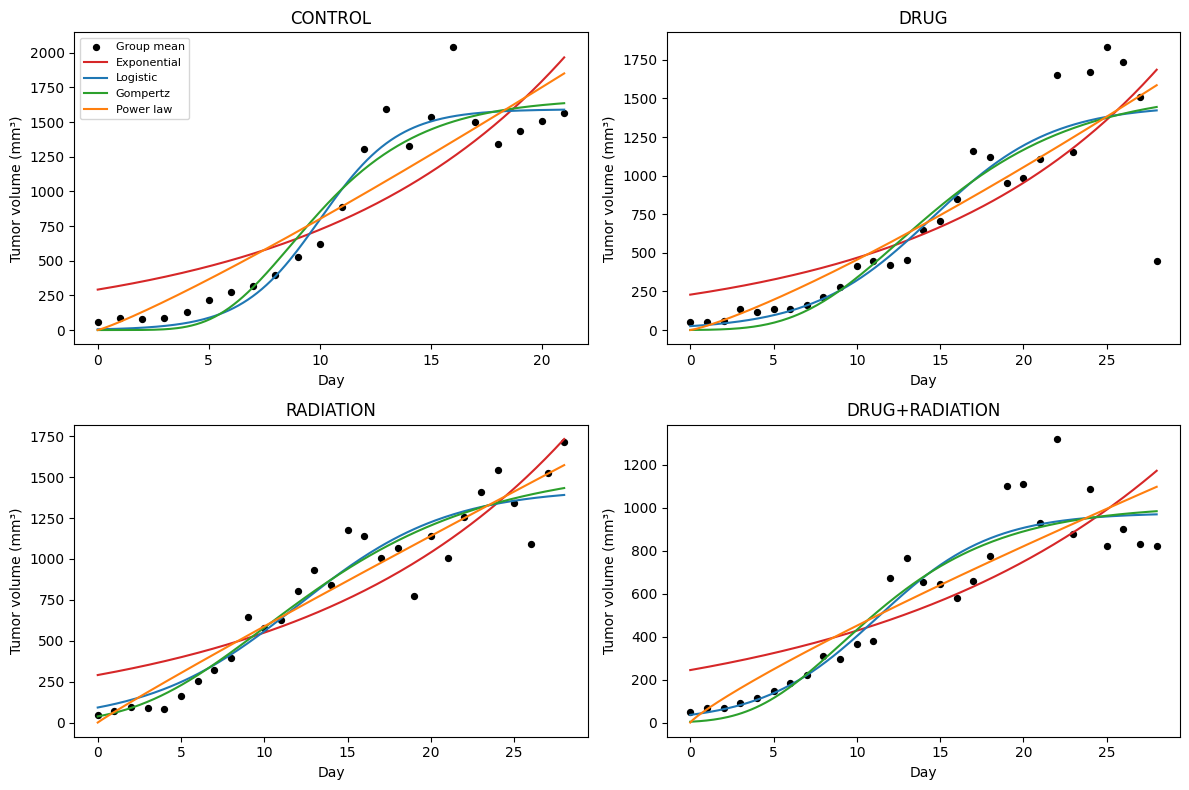

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, g in zip(axes.ravel(), GROUPS):
    t, y = group_mean(g); tt = np.linspace(0, t.max(), 200)
    ax.scatter(t, y, color="black", s=18, label="Group mean")
    for name, c in zip(MODELS, ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]):
        ax.plot(tt, MODELS[name](tt, *fits[(g, name)]), color=c, label=name)
    ax.set_title(g); ax.set_xlabel("Day"); ax.set_ylabel("Tumor volume (mm³)")
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/model_fits.png", dpi=150); plt.show()

## 5. Is the starting volume sensible? (affects growth-rate and doubling-time claims)
In the free fits above, the model's starting volume V0 is allowed to be anything. Compare the fitted V0 with the **actual** mean starting volume (about 50 mm³). If V0 is far off, the growth rate r is distorted, and so is any doubling time computed from it.

In [7]:
rows = []
for g in GROUPS:
    t, y = group_mean(g); v0_obs = y[0]
    p_free = fits[(g, "Logistic")]
    p_con = fit_model("Logistic", t, y, v0_bounds=(0.8 * v0_obs, 1.2 * v0_obs))
    early = (t <= 10)
    slope = np.polyfit(t[early], np.log(y[early]), 1)[0]   # observed early exponential growth rate
    rows.append({"Group": g, "Observed start": round(v0_obs, 1),
                 "Fitted V0 (free)": round(p_free[0], 1), "r (free)": round(p_free[1], 3),
                 "Doubling (free), days": round(np.log(2) / p_free[1], 1),
                 "r (V0 constrained)": round(p_con[1], 3),
                 "Observed early r (days 0-10)": round(slope, 3),
                 "Observed doubling, days": round(np.log(2) / slope, 1),
                 "K (free)": round(p_free[2]), "K (V0 constrained)": round(p_con[2])})
pd.DataFrame(rows).set_index("Group").T

Group,CONTROL,DRUG,RADIATION,DRUG+RADIATION
Observed start,55.600,51.800,48.600,51.100
Fitted V0 (free),5.500,25.100,91.900,35.700
r (free),0.567,0.278,0.223,0.292
"Doubling (free), days",1.200,2.500,3.100,2.400
r (V0 constrained),0.362,0.242,0.271,0.279
Observed early r (days 0-10),0.250,0.195,0.266,0.206
"Observed doubling, days",2.800,3.600,2.600,3.400
K (free),1592.000,1456.000,1430.000,976.000
K (V0 constrained),1672.000,1499.000,1363.000,982.000


## 6. Prediction test with real error numbers
Fit on the **first 70% of days**, predict the **last 30%**, and report the error. Lower RMSE is better. "Bias" is the average of (prediction − actual): positive means the model over-predicts.

In [8]:
rows = []
for g in GROUPS:
    t, y = group_mean(g); cut = int(round(0.7 * len(t)))
    row = {"Group": g, "Train days": cut, "Test days": len(t) - cut}
    for name, f in MODELS.items():
        try:
            p = fit_model(name, t[:cut], y[:cut]); pred = f(t[cut:], *p)
            row[name + " RMSE"] = round(np.sqrt(np.mean((y[cut:] - pred) ** 2)))
            row[name + " bias"] = round(np.mean(pred - y[cut:]))
        except Exception:
            row[name + " RMSE"] = np.nan; row[name + " bias"] = np.nan
    rows.append(row)
holdout = pd.DataFrame(rows).set_index("Group")
rmse_cols = [c for c in holdout.columns if c.endswith("RMSE")]
print("Lowest test RMSE in each group:")
print(holdout[rmse_cols].idxmin(axis=1).str.replace(" RMSE", ""))
holdout

Lowest test RMSE in each group:
Group
CONTROL            Logistic
DRUG               Logistic
RADIATION         Power law
DRUG+RADIATION     Logistic
dtype: str


,Train days,Test days,Exponential RMSE,Exponential bias,Logistic RMSE,Logistic bias,Gompertz RMSE,Gompertz bias,Power law RMSE,Power law bias
Group,,,,,,,,,,
CONTROL,15,7,3272,2687,425,324,1055,897,1588,1346
DRUG,20,9,1626,1232,428,38,606,326,768,491
RADIATION,20,9,814,714,368,-295,338,-260,224,150
DRUG+RADIATION,20,9,1113,896,183,4,272,142,445,314


## 7. Robustness check: fit each mouse on its own
The group average hides differences between mice. Here every mouse (all have 6+ measurements) gets its own fit, and the model with the best small-sample-corrected AIC (AICc) is chosen per mouse.

In [9]:
counts = {}
for mid, d in df.groupby("Mouse_ID"):
    d = d.sort_values("Day"); t = d.Day.values.astype(float); y = d.Tumor_Volume_mm3.values; n = len(t)
    if n < 6: continue
    aiccs = {}
    for name in MODELS:
        try:
            p = fit_model(name, t, y); aiccs[name] = score(y, MODELS[name](t, *p), len(p))[3]
        except Exception:
            pass
    if aiccs:
        key = (d.Treatment_Group.iloc[0], min(aiccs, key=aiccs.get))
        counts[key] = counts.get(key, 0) + 1
per_mouse = pd.Series(counts).unstack(fill_value=0).reindex(GROUPS)
per_mouse.loc["TOTAL"] = per_mouse.sum()
per_mouse

,Exponential,Gompertz,Logistic,Power law
CONTROL,4,0,2,2
DRUG,3,0,1,6
RADIATION,5,3,1,1
DRUG+RADIATION,2,3,2,2
TOTAL,14,6,6,11


## 8. Sensitivity: use only days with at least 3 mice
Repeat the group-mean fits but drop days where fewer than 3 mice contributed to the average.

In [10]:
rows = []
for g in GROUPS:
    d = df[df.Treatment_Group == g]; c = d.groupby("Day").Mouse_ID.nunique()
    m = d[d.Day.isin(c[c >= 3].index)].groupby("Day").Tumor_Volume_mm3.mean()
    t, y = m.index.values.astype(float), m.values
    for name in ["Exponential", "Logistic", "Gompertz"]:
        p = fit_model(name, t, y); r2, rmse, aic, aicc = score(y, MODELS[name](t, *p), len(p))
        rows.append({"Group": g, "Model": name, "Last day used": int(t.max()), "R2": round(r2, 3),
                     "AIC": round(aic, 1), "K": round(p[2]) if len(p) == 3 else None})
pd.DataFrame(rows)

,Group,Model,Last day used,R2,AIC,K
0,CONTROL,Exponential,15,0.922,164.5,NaN
1,CONTROL,Logistic,15,0.964,154.1,1852.0
2,CONTROL,Gompertz,15,0.954,158.0,3005.0
3,DRUG,Exponential,27,0.892,284.8,NaN
4,DRUG,Logistic,27,0.941,270.3,1904.0
5,DRUG,Gompertz,27,0.940,270.9,2623.0
6,RADIATION,Exponential,28,0.805,282.4,NaN
7,RADIATION,Logistic,28,0.899,267.4,1353.0
8,RADIATION,Gompertz,28,0.911,264.0,1487.0
9,DRUG+RADIATION,Exponential,28,0.706,290.6,NaN


## 9. What the evidence supports

**Supported by the data**
- The Exponential model fits worst on the group-mean curves in all four groups. Logistic or Gompertz fit best there.
- Logistic gives the best AIC in 3 of 4 groups (Gompertz in Radiation), and the Exponential model has the lowest R² in every group.
- Fewer mice in the Drug+Radiation group reached large tumor volumes by their last measurement (2 of 9, versus 8 of 8 in Control), which is worth following up with a time-to-threshold analysis.

**Needs a caveat**
- **The group-mean "plateau" is partly a dropout effect.** Most mice left the study with large tumors, so late-day means rest on very few mice. Carrying-capacity values (K) are therefore not reliable, especially for Control, which ends at day 21 and drops to 1-2 mice. Claims about K (such as "combination therapy most effectively limits maximum tumor size") are not supported by this analysis alone.
- **Growth rate and doubling time depend on V0.** When V0 is left free, it can land far from the real starting volume (for example 5.5 vs. an observed 55.6 mm³ in Control) and distort r. With V0 constrained, Control's r drops from 0.567 to 0.362, and the ranking of groups by r changes, so the statement that Radiation has the lowest growth rate is not robust. Doubling times should come from constrained or observed early growth (about 2.6-3.6 days across groups), not from the free fits (1.2-3.1 days).
- **Logistic vs. Gompertz for prediction is not settled.** In the 70/30 test above, compare the RMSE and bias columns directly rather than relying on the visual impression.
- **At the individual-mouse level, the sigmoid models do not dominate.** Exponential and Power-law fits are chosen for many mice (see section 7), which matches the known point that individual tumor data often lie in the early growth phase.

**Next steps if extending this work**
- A mixed-effects model that treats mice as random effects.
- A time-to-threshold comparison (days until each mouse reaches a set volume), which avoids the averaging problem.
- Confidence intervals on parameters (bootstrap by mouse).